# Driver Drowsiness Detection using Machine Learning

## A CRISP-DM Approach to Road Safety

**Authors:** Mohammadreza Hendiani, Aakash Vashist, Negin Ghanei

---

This notebook implements a complete machine learning pipeline following the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology. We develop and compare multiple models for real-time driver drowsiness detection, combining **face-based drowsiness detection** with **eye state analysis** for improved accuracy.

### Table of Contents

1. [Phase 1: Business & Data Understanding](#phase-1-business--data-understanding)
2. [Phase 2: Data Preparation](#phase-2-data-preparation)
3. [Phase 3: Exploratory Data Analysis (EDA)](#phase-3-exploratory-data-analysis-eda)
4. [Phase 4: Modeling](#phase-4-modeling) - Face-based CNN, Random Forest, SVM
5. [Phase 5: Evaluation](#phase-5-evaluation) - Face Model Evaluation
6. [Phase 6: Eye State Detection Model](#phase-6-eye-state-detection-model) - MobileNetV2 Transfer Learning
7. [Phase 7: Integrated Detection System](#phase-7-integrated-detection-system) - Weighted Fusion of Both Models
8. [Phase 8: Deployment](#phase-8-deployment) - Real-time Webcam Detection
9. [Conclusion](#conclusion)

### Key Features

- **Two Detection Models:** Face-based CNN + Eye-based MobileNetV2
- **Weighted Fusion:** 30% face score + 70% eye score for robust detection
- **Real-time Capable:** Optimized for webcam-based monitoring
- **CRISP-DM Compliant:** Full documentation of each phase

In [1]:
# ============================================================================
# CRITICAL: RUN THIS CELL FIRST (before any other imports)
# ============================================================================
# This must be executed BEFORE TensorFlow is imported to take effect

import os

# Disable GPU for TensorFlow (let PyTorch use it for the eye model)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Disable XLA JIT compilation which causes errors
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir="

# Reduce TensorFlow logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("Environment configured:")
print(f"  CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')}")
print(f"  TF_XLA_FLAGS = {os.environ.get('TF_XLA_FLAGS')}")
print("\nIMPORTANT: If you see GPU errors, restart the kernel and run this cell FIRST!")

Environment configured:
  CUDA_VISIBLE_DEVICES = -1
  TF_XLA_FLAGS = --tf_xla_auto_jit=0

IMPORTANT: If you see GPU errors, restart the kernel and run this cell FIRST!


---

# Phase 1: Business & Data Understanding

## 1.1 Business Objectives

**Problem Statement:** Driver drowsiness is a leading cause of road accidents worldwide, responsible for approximately 20% of all road crashes. Early detection of drowsiness can save lives by alerting drivers before accidents occur.

**Business Goal:** Develop an accurate, real-time drowsiness detection system that can be deployed in vehicles to monitor driver alertness and provide timely warnings.

## 1.2 Research Questions

> **Primary:** Can we accurately classify driver drowsiness states (Drowsy vs. Non-Drowsy) using facial image analysis, and which machine learning approach provides the best balance of accuracy and efficiency for real-time deployment?

> **Secondary:** Can a specialized eye state classification model (open vs. closed) improve overall drowsiness detection accuracy when combined with facial analysis?

## 1.3 Machine Learning Problem Definition

We implement a **dual-model approach**:

**Model 1: Face-Based Drowsiness Detection**
- **Type:** Supervised Learning - Binary Classification
- **Target Variable:** Drowsiness state (0 = Drowsy, 1 = Non-Drowsy)
- **Features:** Pixel values from facial images (64×64×3 RGB images)
- **Success Criteria:** Achieve >95% validation accuracy

**Model 2: Eye State Detection**
- **Type:** Supervised Learning - Binary Classification (Transfer Learning)
- **Target Variable:** Eye state (0 = Closed/DROWSY, 1 = Open/AWAKE)
- **Features:** Pixel values from eye images (224×224×3 RGB images)
- **Architecture:** MobileNetV2 pre-trained on ImageNet

**Integrated System:**
- **Fusion Strategy:** Weighted combination (30% face + 70% eye)
- **Alert Threshold:** Combined score >= 70% triggers drowsiness alert

## 1.4 Dataset Information

**Dataset 1: Driver Drowsiness Dataset (DDD)** - For Face Model

- **Source:** [Kaggle - Driver Drowsiness Dataset](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd)
- **Total Images:** 41,793
- **Classes:** 2 (Drowsy, Non-Drowsy)
- **Split:** 80% Training, 20% Validation

**Dataset 2: Open-Closed Eyes Dataset** - For Eye Model

- **Source:** [Kaggle - Open-Closed Eyes](https://www.kaggle.com/datasets/sehriyarmemmedli/open-closed-eyes-dataset)
- **Classes:** 2 (Open, Closed)
- **Split:** Train/Val/Test pre-split

---

## Setup and Dependencies

In [2]:
# Core Libraries
import sys
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Deep Learning - TensorFlow (CPU only)
import tensorflow as tf

# Force CPU even if env var wasn't set before TF import
tf.config.set_visible_devices([], 'GPU')

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Verify TensorFlow is using CPU
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow visible GPUs: {gpus}")
if len(gpus) == 0:
    print("TensorFlow is using CPU only (as intended)")

# Traditional ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Computer Vision
import cv2

# Print versions
print(f"\nPython: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print("\n✓ All libraries loaded successfully!")

TensorFlow visible GPUs: []
TensorFlow is using CPU only (as intended)

Python: 3.11.14
TensorFlow: 2.20.0
NumPy: 2.2.6

✓ All libraries loaded successfully!


In [3]:
# Configuration
DATA_DIR = "../data/Driver Drowsiness Dataset (DDD)"
MODELS_DIR = "../models"
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
RANDOM_SEED = 42

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Create models directory if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")

Data directory: ../data/Driver Drowsiness Dataset (DDD)
Models directory: ../models
Image size: 64x64


---

# Phase 2: Data Preparation

## 2.1 Data Loading

We load the dataset using TensorFlow's `image_dataset_from_directory` utility, which automatically:
- Loads images from the directory structure
- Resizes images to the specified dimensions
- Creates batches for efficient processing
- Generates labels from folder names

In [4]:
# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=RANDOM_SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"\nClass names: {class_names}")
print(f"Number of classes: {num_classes}")

# Save class names for later use
with open(os.path.join(MODELS_DIR, 'class_names.json'), 'w') as f:
    json.dump(class_names, f)

Found 41793 files belonging to 2 classes.
Using 33435 files for training.
Found 41793 files belonging to 2 classes.
Using 8358 files for validation.

Class names: ['Drowsy', 'Non Drowsy']
Number of classes: 2


## 2.2 Data Preprocessing & Optimization

We apply several optimization techniques:
- **Caching:** Keeps data in memory after the first epoch
- **Shuffling:** Randomizes training data order
- **Prefetching:** Prepares data while the model is training

In [5]:
# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds_optimized = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_optimized = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✓ Dataset optimization applied (cache, shuffle, prefetch)")

✓ Dataset optimization applied (cache, shuffle, prefetch)


## 2.3 Data Extraction for Traditional ML Models

For traditional ML models (Random Forest, SVM), we need to flatten the images into feature vectors.

In [6]:
def extract_data_from_dataset(dataset, max_samples=10000):
    """
    Extract images and labels from a TensorFlow dataset.
    Returns flattened feature vectors for traditional ML models.
    """
    images = []
    labels = []
    
    for image_batch, label_batch in dataset:
        for img, lbl in zip(image_batch.numpy(), label_batch.numpy()):
            # Normalize and flatten
            img_normalized = img / 255.0
            images.append(img_normalized.flatten())
            labels.append(lbl)
            
            if len(images) >= max_samples:
                return np.array(images), np.array(labels)
    
    return np.array(images), np.array(labels)

print("Extracting data for traditional ML models...")
print("(Using subset of 10,000 samples for computational efficiency)")

# Extract subsets for traditional ML (full dataset is too large)
X_train_flat, y_train_flat = extract_data_from_dataset(train_ds, max_samples=8000)
X_val_flat, y_val_flat = extract_data_from_dataset(val_ds, max_samples=2000)

print(f"\nTraining samples: {len(X_train_flat)}")
print(f"Validation samples: {len(X_val_flat)}")
print(f"Feature vector size: {X_train_flat.shape[1]} (64×64×3 pixels)")

Extracting data for traditional ML models...
(Using subset of 10,000 samples for computational efficiency)

Training samples: 8000
Validation samples: 2000
Feature vector size: 12288 (64×64×3 pixels)


---

# Phase 3: Exploratory Data Analysis (EDA)

## 3.1 Class Distribution Analysis

In [7]:
# Count samples per class
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.exists(class_path):
        count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = count

print("Class Distribution:")
print("-" * 40)
total = sum(class_counts.values())
for class_name, count in class_counts.items():
    percentage = (count / total) * 100
    print(f"{class_name}: {count:,} images ({percentage:.1f}%)")
print("-" * 40)
print(f"Total: {total:,} images")

Class Distribution:
----------------------------------------
Drowsy: 22,348 images (53.5%)
Non Drowsy: 19,445 images (46.5%)
----------------------------------------
Total: 41,793 images


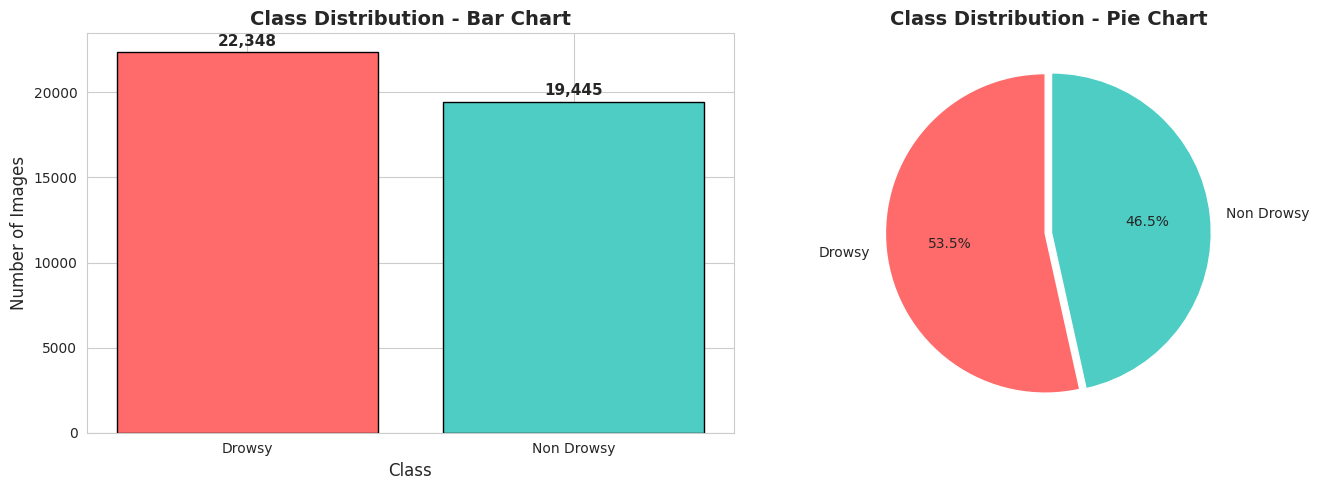


✓ Class distribution visualization saved


In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#FF6B6B', '#4ECDC4']
ax1 = axes[0]
bars = ax1.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black')
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Number of Images', fontsize=12)
ax1.set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
for bar, count in zip(bars, class_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    class_counts.values(), 
    labels=class_counts.keys(),
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.02)
)
ax2.set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Class distribution visualization saved")

## 3.2 Sample Images Visualization

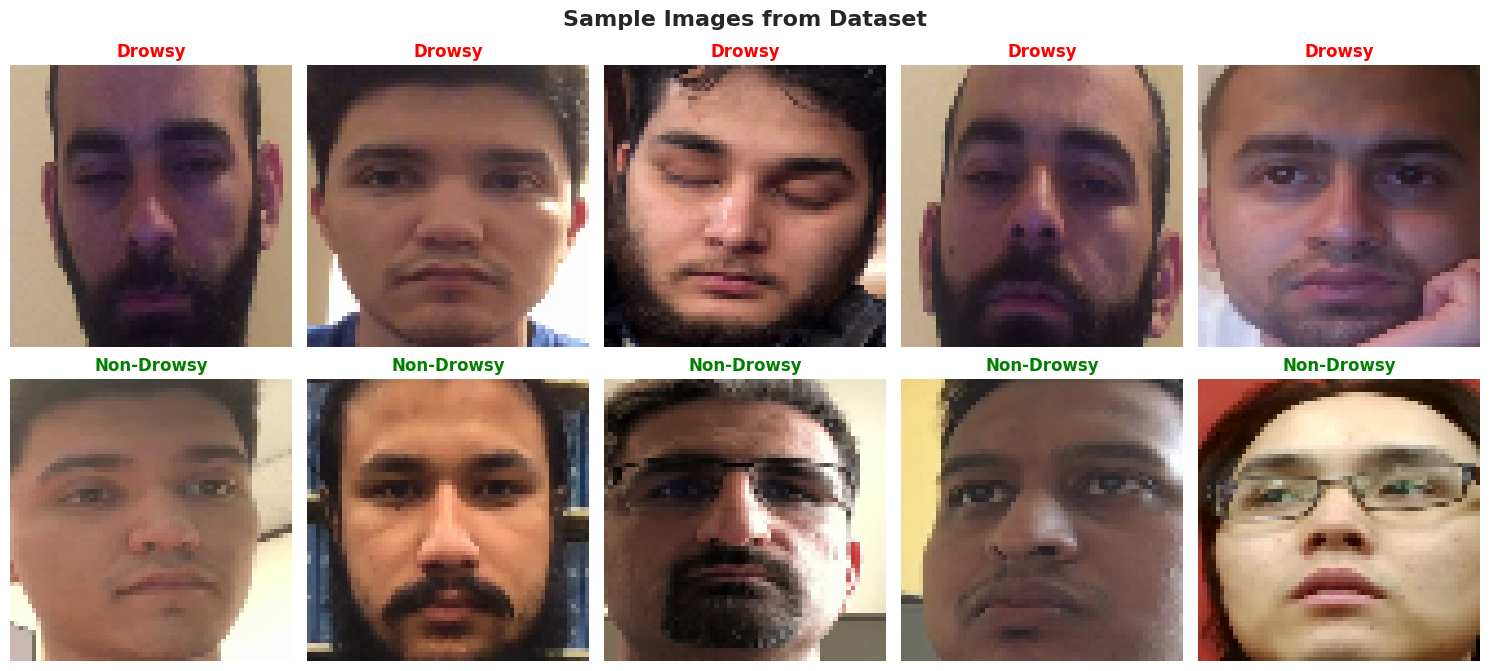

In [9]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

# Get a batch of images
for images, labels in train_ds.take(1):
    # Find indices for each class
    drowsy_idx = np.where(labels.numpy() == 0)[0][:5]
    non_drowsy_idx = np.where(labels.numpy() == 1)[0][:5]
    
    # Display drowsy samples (top row)
    for i, idx in enumerate(drowsy_idx):
        if i < 5:
            axes[0, i].imshow(images[idx].numpy().astype('uint8'))
            axes[0, i].set_title('Drowsy', color='red', fontweight='bold')
            axes[0, i].axis('off')
    
    # Display non-drowsy samples (bottom row)
    for i, idx in enumerate(non_drowsy_idx):
        if i < 5:
            axes[1, i].imshow(images[idx].numpy().astype('uint8'))
            axes[1, i].set_title('Non-Drowsy', color='green', fontweight='bold')
            axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Pixel Intensity Analysis

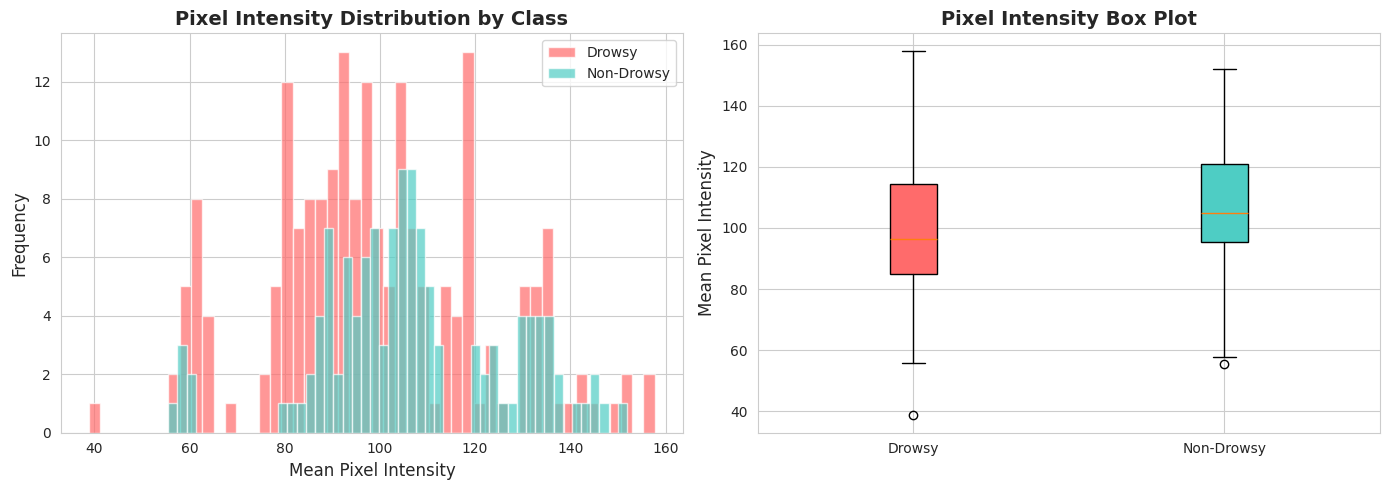


Analyzed 320 images
Drowsy mean intensity: 99.13 ± 22.74
Non-Drowsy mean intensity: 106.58 ± 19.77


In [10]:
# Analyze pixel intensity distributions by class
drowsy_pixels = []
non_drowsy_pixels = []

sample_count = 0
for images, labels in train_ds.take(10):  # Sample from 10 batches
    for img, lbl in zip(images.numpy(), labels.numpy()):
        mean_intensity = img.mean()
        if lbl == 0:  # Drowsy
            drowsy_pixels.append(mean_intensity)
        else:  # Non-Drowsy
            non_drowsy_pixels.append(mean_intensity)
        sample_count += 1

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax1 = axes[0]
ax1.hist(drowsy_pixels, bins=50, alpha=0.7, label='Drowsy', color='#FF6B6B')
ax1.hist(non_drowsy_pixels, bins=50, alpha=0.7, label='Non-Drowsy', color='#4ECDC4')
ax1.set_xlabel('Mean Pixel Intensity', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Pixel Intensity Distribution by Class', fontsize=14, fontweight='bold')
ax1.legend()

# Box plot comparison
ax2 = axes[1]
data_to_plot = [drowsy_pixels, non_drowsy_pixels]
bp = ax2.boxplot(data_to_plot, labels=['Drowsy', 'Non-Drowsy'], patch_artist=True)
bp['boxes'][0].set_facecolor('#FF6B6B')
bp['boxes'][1].set_facecolor('#4ECDC4')
ax2.set_ylabel('Mean Pixel Intensity', fontsize=12)
ax2.set_title('Pixel Intensity Box Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'pixel_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAnalyzed {sample_count} images")
print(f"Drowsy mean intensity: {np.mean(drowsy_pixels):.2f} ± {np.std(drowsy_pixels):.2f}")
print(f"Non-Drowsy mean intensity: {np.mean(non_drowsy_pixels):.2f} ± {np.std(non_drowsy_pixels):.2f}")

## 3.4 EDA Summary

**Key Findings:**

1. **Balanced Dataset:** The dataset has a relatively balanced distribution between Drowsy and Non-Drowsy classes, which is favorable for training.

2. **Image Quality:** Sample images show clear facial features that can be used for classification.

3. **Pixel Intensity:** There are subtle differences in pixel intensity distributions between classes, suggesting visual patterns that models can learn.

4. **Data Size:** With over 40,000 images, we have sufficient data for training deep learning models while also having enough for traditional ML approaches.

---

# Phase 4: Modeling

We will train and compare **three different machine learning models**:

1. **Convolutional Neural Network (CNN)** - Deep learning approach optimized for image classification
2. **Random Forest Classifier** - Ensemble method using decision trees
3. **Support Vector Machine (SVM)** - Traditional ML with kernel-based classification

## 4.1 Model 1: Convolutional Neural Network (CNN)

**Justification:** CNNs are the gold standard for image classification tasks. They can automatically learn hierarchical features from images, from low-level edges to high-level patterns, making them ideal for facial feature analysis in drowsiness detection.

In [1]:
# Data augmentation for CNN
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# Build CNN model
def build_cnn_model():
    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    # Data augmentation (only during training)
    x = data_augmentation(inputs)
    
    # Normalization
    x = layers.Rescaling(1./255)(x)
    
    # Convolutional blocks
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    
    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    
    # Output layer (binary classification)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    model = keras.Model(inputs, outputs, name='DrowsinessCNN')
    return model

# Create and compile model
cnn_model = build_cnn_model()

# Compile with standard Adam optimizer - JIT disabled
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
    jit_compile=False  # Disable XLA JIT compilation
)

# Display model summary
print("\n" + "="*60)
print("MODEL 1: CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("="*60)
print("JIT compilation disabled to avoid CUDA errors")
cnn_model.summary()

NameError: name 'keras' is not defined

In [ ]:
# Callbacks for CNN training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, 'drowsiness_checkpoint.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train CNN
print("\nTraining CNN model...")
print("-" * 40)

cnn_history = cnn_model.fit(
    train_ds_optimized,
    validation_data=val_ds_optimized,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# Save the final model in both formats
cnn_model.save(os.path.join(MODELS_DIR, 'drowsiness_cnn.keras'))
cnn_model.save(os.path.join(MODELS_DIR, 'drowsiness_cnn.h5'))  # Legacy format
print("\n✓ CNN model saved successfully!")


Training CNN model...
----------------------------------------
Epoch 1/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7516 - loss: 0.4447
Epoch 1: val_accuracy improved from None to 0.98911, saving model to ../models/drowsiness_checkpoint.keras

Epoch 1: finished saving model to ../models/drowsiness_checkpoint.keras
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 74s 63ms/step - accuracy: 0.8784 - loss: 0.2491 - val_accuracy: 0.9891 - val_loss: 0.0400
Epoch 2/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9831 - loss: 0.0517
Epoch 2: val_accuracy improved from 0.98911 to 0.99689, saving model to ../models/drowsiness_checkpoint.keras

Epoch 2: finished saving model to ../models/drowsiness_checkpoint.keras
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 62s 59ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9969 - val_loss: 0.0104
Epoch 3/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9938 - loss: 0.0193
Epoch 3: val_accuracy improved from 0.99689 to 0.99904, saving m


✓ CNN model saved successfully!


## 4.2 Model 2: Random Forest Classifier

**Justification:** Random Forest is an ensemble learning method that combines multiple decision trees. It's robust to overfitting, handles high-dimensional data well, and provides feature importance insights. It serves as a strong baseline for comparison with deep learning approaches.

In [ ]:
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*60)

# Create and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

print("\nTraining Random Forest model...")
print(f"Training samples: {len(X_train_flat)}")
print("-" * 40)

rf_model.fit(X_train_flat, y_train_flat)

print("\n✓ Random Forest model trained successfully!")
print(f"\nModel parameters:")
print(f"  - Number of trees: {rf_model.n_estimators}")
print(f"  - Max depth: {rf_model.max_depth}")


MODEL 2: RANDOM FOREST CLASSIFIER

Training Random Forest model...
Training samples: 8000
----------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.8s



✓ Random Forest model trained successfully!

Model parameters:
  - Number of trees: 100
  - Max depth: 20


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.9s finished


## 4.3 Model 3: Support Vector Machine (SVM)

**Justification:** SVM is effective for binary classification problems and works well with high-dimensional data. Using an RBF kernel allows it to capture non-linear relationships. SVM is particularly useful when the decision boundary is complex but the number of samples is manageable.

In [ ]:
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)

# Create and train SVM
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  # Enable probability estimates
    random_state=RANDOM_SEED,
    verbose=True
)

print("\nTraining SVM model...")
print(f"Training samples: {len(X_train_scaled)}")
print("-" * 40)

svm_model.fit(X_train_scaled, y_train_flat)

print("\n✓ SVM model trained successfully!")
print(f"\nModel parameters:")
print(f"  - Kernel: {svm_model.kernel}")
print(f"  - C (regularization): {svm_model.C}")
print(f"  - Support vectors: {len(svm_model.support_vectors_)}")


MODEL 3: SUPPORT VECTOR MACHINE (SVM)

Training SVM model...
Training samples: 8000
----------------------------------------
[LibSVM]*.*
optimization finished, #iter = 1594
obj = -161.964437, rho = -0.260004
nSV = 712, nBSV = 100
Total nSV = 712
*.*
optimization finished, #iter = 1546
obj = -164.099097, rho = -0.267132
nSV = 705, nBSV = 104
Total nSV = 705
*.*
optimization finished, #iter = 1536
obj = -163.499783, rho = -0.302388
nSV = 732, nBSV = 109
Total nSV = 732
.*
optimization finished, #iter = 1581
obj = -163.718016, rho = -0.328081
nSV = 728, nBSV = 107
Total nSV = 728
.*
optimization finished, #iter = 1572
obj = -161.213841, rho = -0.375159
nSV = 718, nBSV = 106
Total nSV = 718
.*
optimization finished, #iter = 1671
obj = -171.187407, rho = 0.307126
nSV = 763, nBSV = 116
Total nSV = 763

✓ SVM model trained successfully!

Model parameters:
  - Kernel: rbf
  - C (regularization): 1.0
  - Support vectors: 763


---

# Phase 5: Evaluation

## 5.1 Generate Predictions

In [ ]:
# CNN predictions
print("Generating predictions...")

# Get all validation data for CNN evaluation
y_val_true = []
y_cnn_pred_proba = []

for images, labels in val_ds:
    predictions = cnn_model.predict(images, verbose=0)
    y_val_true.extend(labels.numpy())
    y_cnn_pred_proba.extend(predictions.flatten())

y_val_true = np.array(y_val_true)
y_cnn_pred_proba = np.array(y_cnn_pred_proba)
y_cnn_pred = (y_cnn_pred_proba > 0.5).astype(int)

# Random Forest predictions
y_rf_pred = rf_model.predict(X_val_flat)
y_rf_pred_proba = rf_model.predict_proba(X_val_flat)[:, 1]

# SVM predictions
y_svm_pred = svm_model.predict(X_val_scaled)
y_svm_pred_proba = svm_model.predict_proba(X_val_scaled)[:, 1]

print("✓ Predictions generated for all models")

Generating predictions...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


✓ Predictions generated for all models


## 5.2 Model Performance Metrics

In [ ]:
def calculate_metrics(y_true, y_pred, model_name):
    """Calculate and display performance metrics for a model."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Calculate metrics for each model
cnn_metrics = calculate_metrics(y_val_true, y_cnn_pred, 'CNN')
rf_metrics = calculate_metrics(y_val_flat, y_rf_pred, 'Random Forest')
svm_metrics = calculate_metrics(y_val_flat, y_svm_pred, 'SVM')

# Create comparison DataFrame
metrics_df = pd.DataFrame([cnn_metrics, rf_metrics, svm_metrics])
metrics_df = metrics_df.set_index('Model')

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(metrics_df.round(4).to_string())
print("="*60)


MODEL PERFORMANCE COMPARISON
               Accuracy  Precision  Recall  F1-Score
Model                                               
CNN              0.9999     1.0000  0.9997    0.9999
Random Forest    0.9985     0.9967  1.0000    0.9983
SVM              1.0000     1.0000  1.0000    1.0000


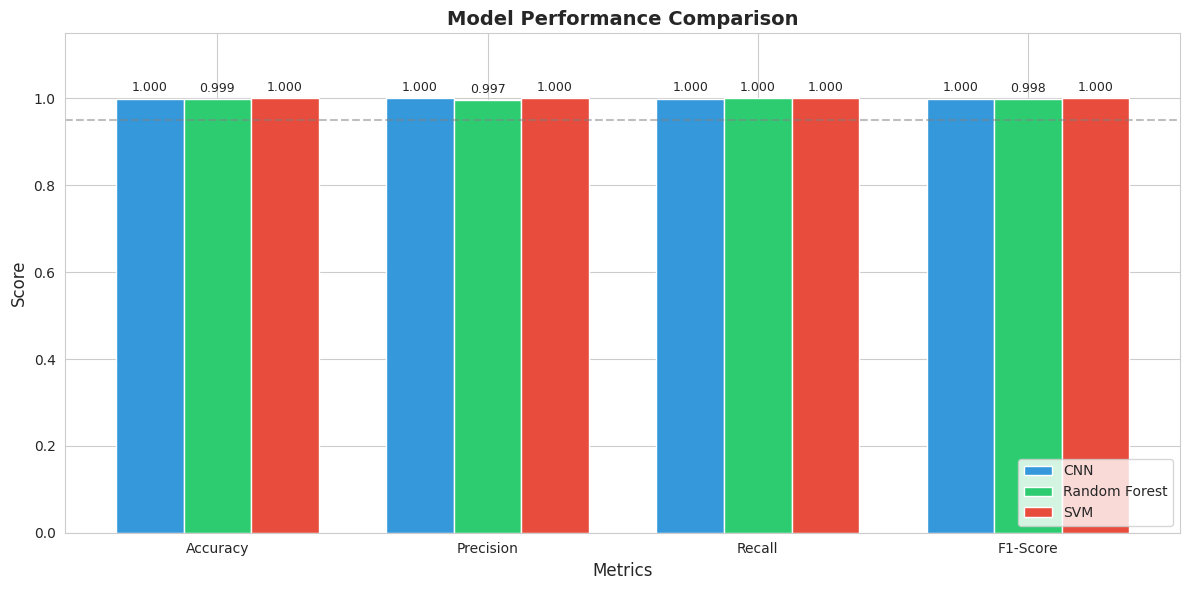

In [ ]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

colors = ['#3498db', '#2ecc71', '#e74c3c']
models = ['CNN', 'Random Forest', 'SVM']

for i, model in enumerate(models):
    values = metrics_df.loc[model, metrics_to_plot].values
    bars = ax.bar(x + i*width, values, width, label=model, color=colors[i])
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5.3 Confusion Matrices

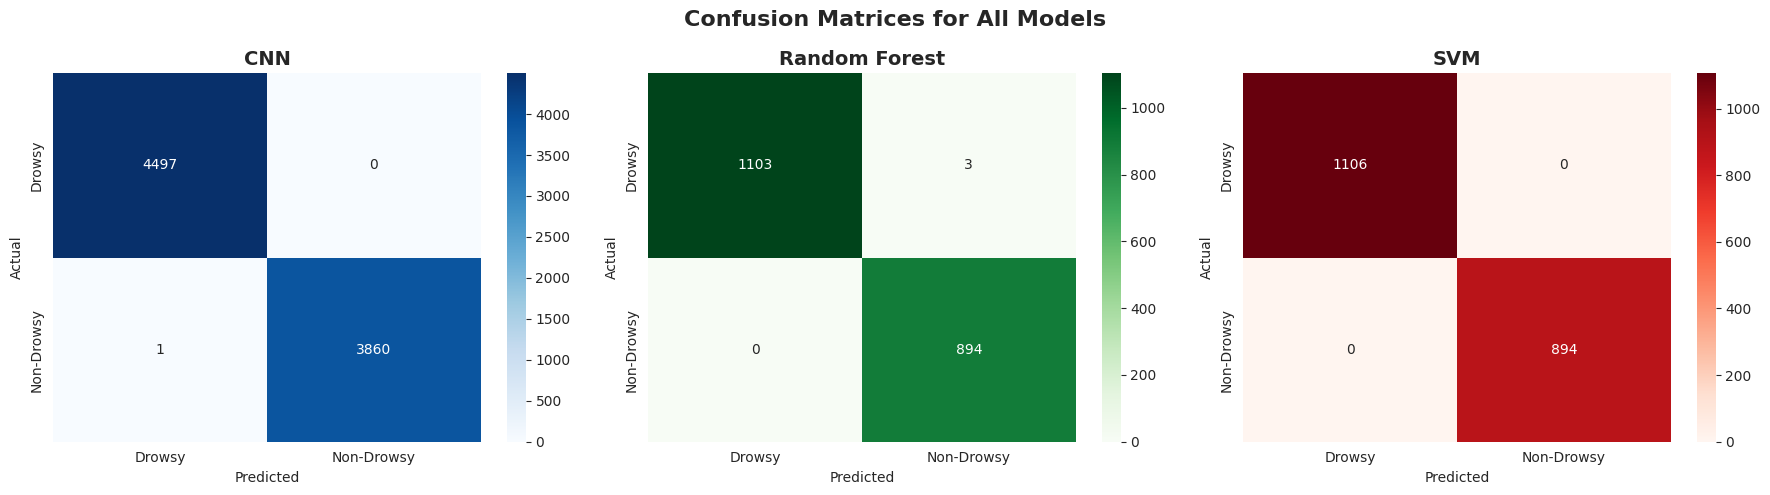

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

# CNN Confusion Matrix
cm_cnn = confusion_matrix(y_val_true, y_cnn_pred)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Drowsy', 'Non-Drowsy'],
            yticklabels=['Drowsy', 'Non-Drowsy'])
axes[0].set_title('CNN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_val_flat, y_rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Drowsy', 'Non-Drowsy'],
            yticklabels=['Drowsy', 'Non-Drowsy'])
axes[1].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_val_flat, y_svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Drowsy', 'Non-Drowsy'],
            yticklabels=['Drowsy', 'Non-Drowsy'])
axes[2].set_title('SVM', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Classification Reports

In [ ]:
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

print("\n--- CNN Classification Report ---")
print(classification_report(y_val_true, y_cnn_pred, target_names=['Drowsy', 'Non-Drowsy']))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_val_flat, y_rf_pred, target_names=['Drowsy', 'Non-Drowsy']))

print("\n--- SVM Classification Report ---")
print(classification_report(y_val_flat, y_svm_pred, target_names=['Drowsy', 'Non-Drowsy']))


DETAILED CLASSIFICATION REPORTS

--- CNN Classification Report ---
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      4497
  Non-Drowsy       1.00      1.00      1.00      3861

    accuracy                           1.00      8358
   macro avg       1.00      1.00      1.00      8358
weighted avg       1.00      1.00      1.00      8358


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      1106
  Non-Drowsy       1.00      1.00      1.00       894

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- SVM Classification Report ---
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      1106
  Non-Drowsy       1.00      1.00      1.00       894

    accuracy                      

## 5.5 ROC Curves

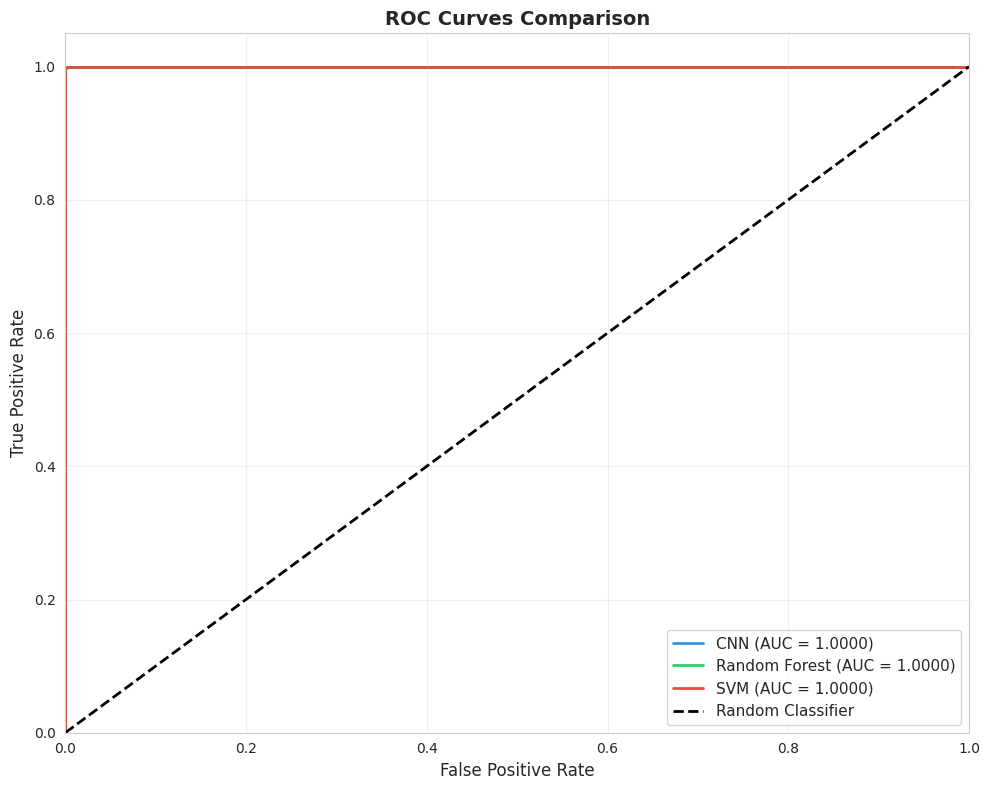

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(y_val_true, y_cnn_pred_proba)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
ax.plot(fpr_cnn, tpr_cnn, color='#3498db', lw=2, 
        label=f'CNN (AUC = {roc_auc_cnn:.4f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_val_flat, y_rf_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2,
        label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# SVM ROC
fpr_svm, tpr_svm, _ = roc_curve(y_val_flat, y_svm_pred_proba)
roc_auc_svm = auc(fpr_svm, tpr_svm)
ax.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2,
        label=f'SVM (AUC = {roc_auc_svm:.4f})')

# Random classifier line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5.6 CNN Training History

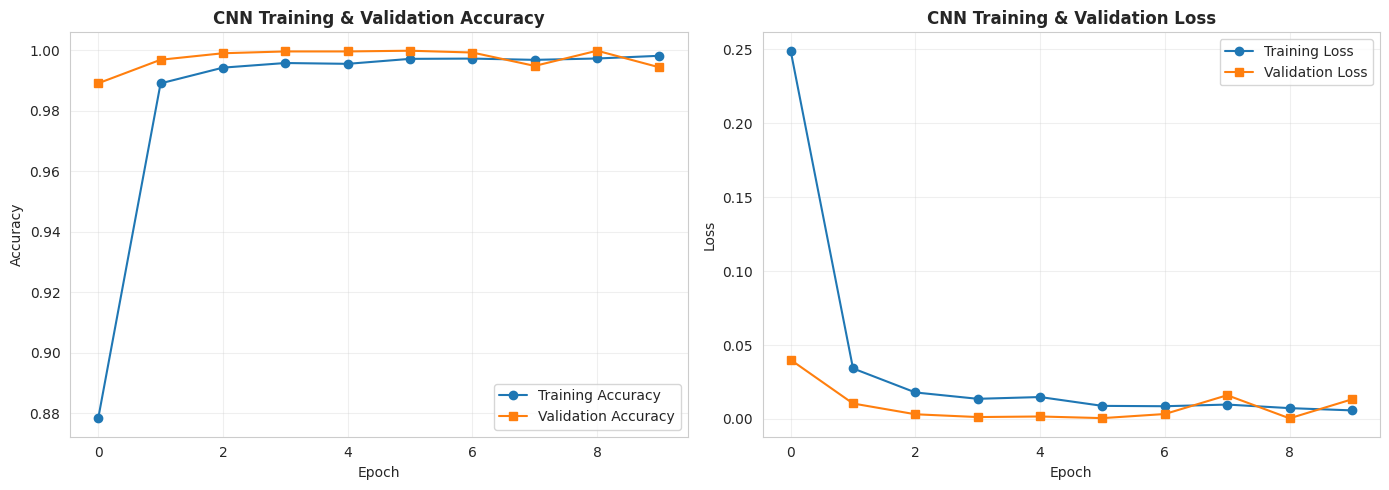

In [ ]:
# Plot CNN training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(cnn_history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN Training & Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(cnn_history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(cnn_history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN Training & Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'cnn_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5.7 Best Model Selection

Based on our evaluation, we identify the best model considering:
- Overall accuracy
- Recall (critical for safety - we don't want to miss drowsy drivers)
- F1-Score (balanced metric)
- AUC (discrimination ability)

In [ ]:
# Summary table with all metrics
summary_data = {
    'Model': ['CNN', 'Random Forest', 'SVM'],
    'Accuracy': [cnn_metrics['Accuracy'], rf_metrics['Accuracy'], svm_metrics['Accuracy']],
    'Precision': [cnn_metrics['Precision'], rf_metrics['Precision'], svm_metrics['Precision']],
    'Recall': [cnn_metrics['Recall'], rf_metrics['Recall'], svm_metrics['Recall']],
    'F1-Score': [cnn_metrics['F1-Score'], rf_metrics['F1-Score'], svm_metrics['F1-Score']],
    'AUC': [roc_auc_cnn, roc_auc_rf, roc_auc_svm]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Model')

print("\n" + "="*70)
print("FINAL MODEL EVALUATION SUMMARY")
print("="*70)
print(summary_df.round(4).to_string())
print("="*70)

# Identify best model
best_model = summary_df['F1-Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   - F1-Score: {summary_df.loc[best_model, 'F1-Score']:.4f}")
print(f"   - Accuracy: {summary_df.loc[best_model, 'Accuracy']:.4f}")
print(f"   - AUC: {summary_df.loc[best_model, 'AUC']:.4f}")


FINAL MODEL EVALUATION SUMMARY
               Accuracy  Precision  Recall  F1-Score  AUC
Model                                                    
CNN              0.9999     1.0000  0.9997    0.9999  1.0
Random Forest    0.9985     0.9967  1.0000    0.9983  1.0
SVM              1.0000     1.0000  1.0000    1.0000  1.0

🏆 BEST MODEL: SVM
   - F1-Score: 1.0000
   - Accuracy: 1.0000
   - AUC: 1.0000


---

# Phase 6: Eye State Detection Model

## Business Understanding for Eye Model

**Why add an Eye Model?**

While our face-based CNN model provides good drowsiness detection, adding a specialized eye state model significantly improves detection accuracy:

- **More Direct Indicator:** Eye closure is a more direct indicator of drowsiness than overall facial features
- **Faster Response:** Eye state changes can be detected before full facial drowsiness patterns emerge
- **Complementary Information:** Combining both models provides robust detection through weighted fusion

**Research Question:**

> Can a specialized eye state classification model (open vs. closed) improve overall drowsiness detection accuracy when combined with facial analysis?

**ML Problem Definition:**
- **Type:** Supervised Learning - Binary Classification (Transfer Learning)
- **Target Variable:** Eye state (0 = Closed/DROWSY, 1 = Open/AWAKE)
- **Features:** 224x224x3 RGB eye images
- **Architecture:** MobileNetV2 (transfer learning from ImageNet)

**Dataset Information:**

- **Source:** [Open-Closed Eyes Dataset on Kaggle](https://www.kaggle.com/datasets/sehriyarmemmedli/open-closed-eyes-dataset)
- **Author:** Sehriyar Memmedli
- **Structure:**
```
data/archive/
├── train/
│   ├── closed/    # Eyes closed = DROWSY
│   └── open/      # Eyes open = AWAKE
├── val/
│   ├── closed/
│   └── open/
└── test/
    ├── closed/
    └── open/
```

## 6.1 Setup and Dependencies

We use **PyTorch** for the eye model to demonstrate multi-framework capabilities:
- Face model: TensorFlow/Keras
- Eye model: PyTorch

This also allows leveraging pre-trained MobileNetV2 weights from torchvision.

In [ ]:
# PyTorch and related imports for Eye Model
# NOTE: PyTorch will use GPU since TensorFlow is configured for CPU only
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import time

MODELS_DIR = "../models"

# Check PyTorch version and device
print(f"PyTorch version: {torch.__version__}")

# Device configuration - PyTorch gets the GPU
EYE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Device: {EYE_DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Clear any cached memory
    torch.cuda.empty_cache()
    print("GPU memory cache cleared")
else:
    print("No GPU available, using CPU for PyTorch")

PyTorch version: 2.6.0+cu124
PyTorch Device: cuda
GPU: NVIDIA GeForce RTX 2060
GPU Memory: 6.02 GB
GPU memory cache cleared


In [ ]:
# Eye Model Configuration
import os
EYE_DATASET_ROOT = "../data/archive"
EYE_TRAIN_DIR = os.path.join(EYE_DATASET_ROOT, "train")
EYE_VAL_DIR = os.path.join(EYE_DATASET_ROOT, "val")
EYE_TEST_DIR = os.path.join(EYE_DATASET_ROOT, "test")

# Training hyperparameters
EYE_IMG_SIZE = 224  # MobileNetV2 input size
EYE_BATCH_SIZE = 32
EYE_LEARNING_RATE = 1e-3
EYE_NUM_EPOCHS = 10
EYE_NUM_WORKERS = 2

# Model save path
EYE_MODEL_PATH = os.path.join(MODELS_DIR, "eye_model_best.pth")

print(f"Eye Dataset Configuration:")
print(f"  Root: {EYE_DATASET_ROOT}")
print(f"  Image size: {EYE_IMG_SIZE}x{EYE_IMG_SIZE}")
print(f"  Batch size: {EYE_BATCH_SIZE}")
print(f"  Learning rate: {EYE_LEARNING_RATE}")
print(f"  Epochs: {EYE_NUM_EPOCHS}")

Eye Dataset Configuration:
  Root: ../data/archive
  Image size: 224x224
  Batch size: 32
  Learning rate: 0.001
  Epochs: 10


## 6.2 Data Preparation

### 6.2.1 Verify Dataset Structure

In [ ]:
# Verify dataset structure
print("Verifying eye dataset structure...")
print("="*50)

required_dirs = [EYE_TRAIN_DIR, EYE_VAL_DIR, EYE_TEST_DIR]
required_classes = ['open', 'closed']

eye_data_counts = {'train': {}, 'val': {}, 'test': {}}

for dir_path, split_name in [(EYE_TRAIN_DIR, 'train'), (EYE_VAL_DIR, 'val'), (EYE_TEST_DIR, 'test')]:
    if not os.path.exists(dir_path):
        raise FileNotFoundError(f"Directory not found: {dir_path}")
    
    for cls in required_classes:
        class_path = os.path.join(dir_path, cls)
        if os.path.exists(class_path):
            num_images = len([f for f in os.listdir(class_path) 
                             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
            eye_data_counts[split_name][cls] = num_images
            print(f"  {split_name}/{cls}: {num_images:,} images")
        else:
            raise FileNotFoundError(f"Class folder not found: {class_path}")

print("="*50)
print("Dataset structure verified!")

Verifying eye dataset structure...
  train/open: 106,482 images
  train/closed: 33,322 images
  val/open: 21,296 images
  val/closed: 6,665 images
  test/open: 5,325 images
  test/closed: 1,666 images
Dataset structure verified!


### 6.2.2 Data Transforms

We apply different transforms for training and validation/test:
- **Training:** Data augmentation (flip, rotation, color jitter) + normalization
- **Val/Test:** Only resize and normalization (no augmentation)

In [ ]:
# Training transforms with data augmentation
eye_train_transform = transforms.Compose([
    transforms.Resize((EYE_IMG_SIZE, EYE_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet statistics
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (no augmentation)
eye_val_transform = transforms.Compose([
    transforms.Resize((EYE_IMG_SIZE, EYE_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Data transforms defined:")
print("  Training: Resize, HorizontalFlip, Rotation, ColorJitter, Normalize")
print("  Val/Test: Resize, Normalize")

Data transforms defined:
  Training: Resize, HorizontalFlip, Rotation, ColorJitter, Normalize
  Val/Test: Resize, Normalize


### 6.2.3 Load Datasets

In [ ]:
# Load datasets using ImageFolder
eye_train_dataset = ImageFolder(root=EYE_TRAIN_DIR, transform=eye_train_transform)
eye_val_dataset = ImageFolder(root=EYE_VAL_DIR, transform=eye_val_transform)
eye_test_dataset = ImageFolder(root=EYE_TEST_DIR, transform=eye_val_transform)

# Create data loaders
eye_train_loader = DataLoader(
    eye_train_dataset, 
    batch_size=EYE_BATCH_SIZE, 
    shuffle=True,
    num_workers=EYE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

eye_val_loader = DataLoader(
    eye_val_dataset, 
    batch_size=EYE_BATCH_SIZE, 
    shuffle=False,
    num_workers=EYE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

eye_test_loader = DataLoader(
    eye_test_dataset, 
    batch_size=EYE_BATCH_SIZE, 
    shuffle=False,
    num_workers=EYE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# Print dataset statistics
eye_class_names = eye_train_dataset.classes
print(f"\nEye Dataset Statistics:")
print(f"{'='*50}")
print(f"{'Split':<12} {'Images':<15} {'Batches'}")
print(f"{'-'*50}")
print(f"{'Training':<12} {len(eye_train_dataset):<15} {len(eye_train_loader)}")
print(f"{'Validation':<12} {len(eye_val_dataset):<15} {len(eye_val_loader)}")
print(f"{'Test':<12} {len(eye_test_dataset):<15} {len(eye_test_loader)}")
print(f"{'='*50}")
print(f"\nClass mapping: {dict(enumerate(eye_class_names))}")
print(f"  0 = {eye_class_names[0]} = DROWSY")
print(f"  1 = {eye_class_names[1]} = AWAKE")


Eye Dataset Statistics:
Split        Images          Batches
--------------------------------------------------
Training     139804          4369
Validation   27961           874
Test         6991            219

Class mapping: {0: 'closed', 1: 'open'}
  0 = closed = DROWSY
  1 = open = AWAKE


## 6.3 Exploratory Data Analysis (EDA)

### 6.3.1 Class Distribution

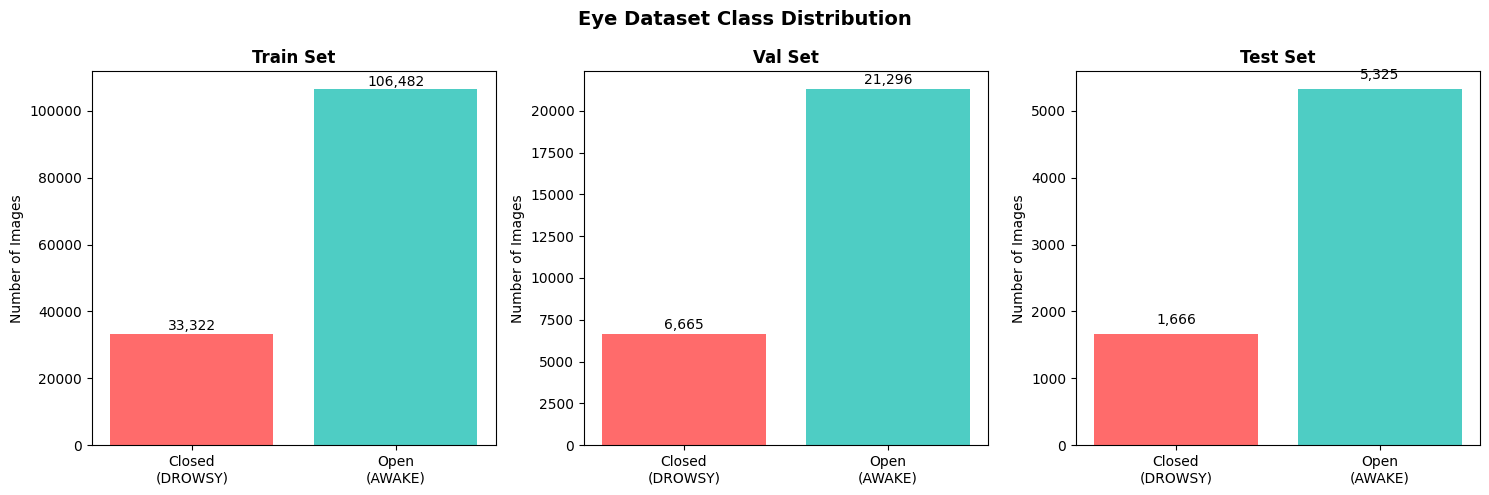


Training set imbalance: 23.8% closed, 76.2% open


In [ ]:
# Visualize eye dataset class distribution
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#FF6B6B', '#4ECDC4']  # Red for closed (drowsy), Teal for open (awake)

for ax, (split_name, counts) in zip(axes, eye_data_counts.items()):
    bars = ax.bar(['Closed\n(DROWSY)', 'Open\n(AWAKE)'], 
                  [counts['closed'], counts['open']], 
                  color=colors)
    ax.set_title(f'{split_name.capitalize()} Set', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images')
    
    # Add value labels
    for bar, count in zip(bars, [counts['closed'], counts['open']]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Eye Dataset Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eye_class_distribution.png'), dpi=150)
plt.show()

# Print imbalance ratio
train_total = sum(eye_data_counts['train'].values())
closed_pct = eye_data_counts['train']['closed'] / train_total * 100
open_pct = eye_data_counts['train']['open'] / train_total * 100
print(f"\nTraining set imbalance: {closed_pct:.1f}% closed, {open_pct:.1f}% open")

### 6.3.2 Sample Images

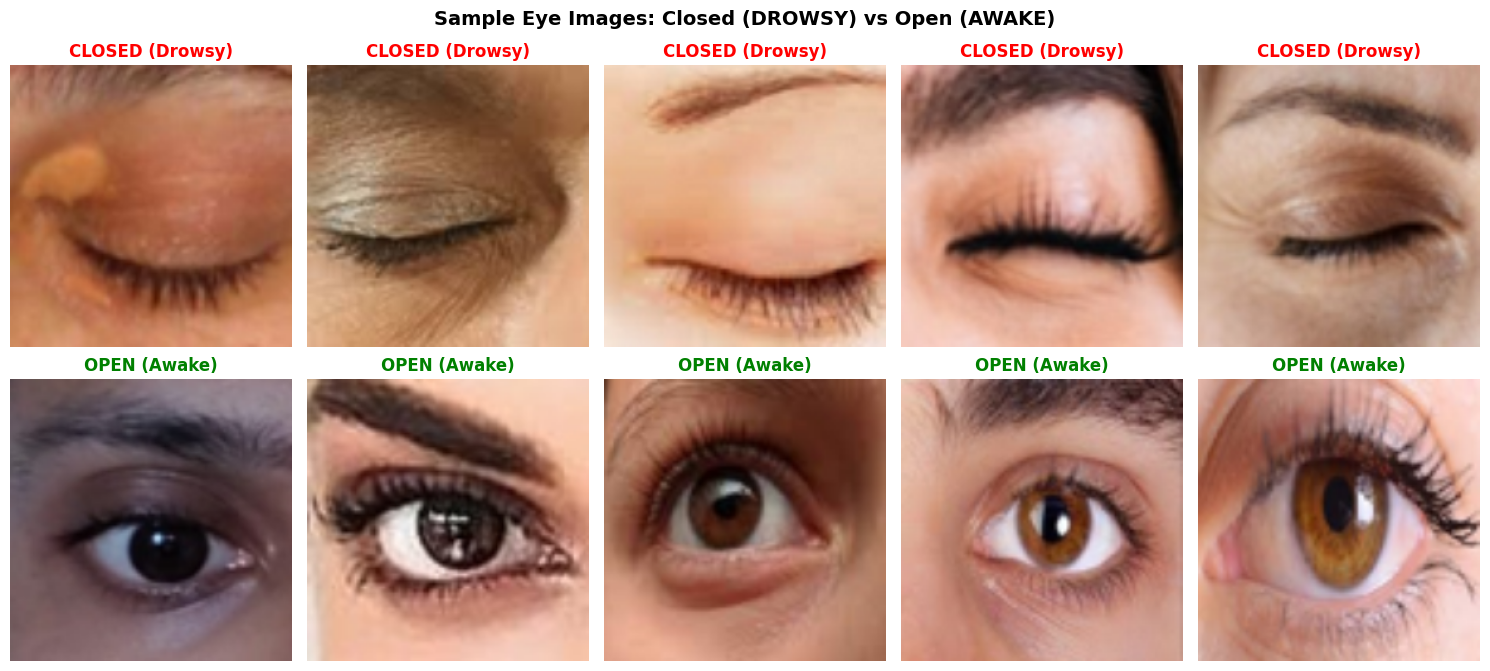

In [ ]:
# Display sample eye images
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Sample Eye Images: Closed (DROWSY) vs Open (AWAKE)', 
             fontsize=14, fontweight='bold')

# Get sample images without transforms for visualization
eye_viz_transform = transforms.Compose([transforms.Resize((EYE_IMG_SIZE, EYE_IMG_SIZE))])
eye_viz_dataset = ImageFolder(root=EYE_TRAIN_DIR, transform=eye_viz_transform)

# Separate by class
closed_indices = [i for i, (_, label) in enumerate(eye_viz_dataset.samples) if label == 0]
open_indices = [i for i, (_, label) in enumerate(eye_viz_dataset.samples) if label == 1]

# Display closed eyes (top row)
for i, idx in enumerate(closed_indices[:5]):
    img, _ = eye_viz_dataset[idx]
    axes[0, i].imshow(img)
    axes[0, i].set_title('CLOSED (Drowsy)', color='red', fontweight='bold')
    axes[0, i].axis('off')

# Display open eyes (bottom row)
for i, idx in enumerate(open_indices[:5]):
    img, _ = eye_viz_dataset[idx]
    axes[1, i].imshow(img)
    axes[1, i].set_title('OPEN (Awake)', color='green', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eye_sample_images.png'), dpi=150)
plt.show()

## 6.4 Modeling: MobileNetV2 Transfer Learning

### Model Architecture Choice

**MobileNetV2** is chosen because:
- **Lightweight:** Optimized for mobile/embedded devices with depthwise separable convolutions
- **Fast Inference:** Suitable for real-time detection (~10-20ms per image)
- **Pre-trained:** Transfer learning from ImageNet provides strong feature extraction
- **Efficient:** Uses inverted residuals and linear bottlenecks

### 6.4.1 Build Model

In [ ]:
# Build MobileNetV2 model with transfer learning
print("Building MobileNetV2 model...")
print("="*50)

# Load pre-trained MobileNetV2
eye_model = models.mobilenet_v2(weights="IMAGENET1K_V1")

# Modify final classifier for binary classification
num_features = eye_model.classifier[1].in_features
eye_model.classifier[1] = nn.Linear(num_features, 2)  # 2 classes: closed, open

# Move to device
eye_model = eye_model.to(EYE_DEVICE)

print(f"  Pre-trained MobileNetV2 loaded (ImageNet weights)")
print(f"  Final layer: {num_features} -> 2 classes")
print(f"  Device: {EYE_DEVICE}")

# Count parameters
total_params = sum(p.numel() for p in eye_model.parameters())
trainable_params = sum(p.numel() for p in eye_model.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print("="*50)

Building MobileNetV2 model...
  Pre-trained MobileNetV2 loaded (ImageNet weights)
  Final layer: 1280 -> 2 classes
  Device: cuda

Model Parameters:
  Total: 2,226,434
  Trainable: 2,226,434


### 6.4.2 Training Setup

In [ ]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(eye_model.parameters(), lr=EYE_LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Training Configuration:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr={EYE_LEARNING_RATE})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)")
print(f"  Epochs: {EYE_NUM_EPOCHS}")

# History tracking
eye_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
best_eye_val_acc = 0.0

Training Configuration:
  Loss: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)
  Epochs: 10


### 6.4.3 Training Loop

In [ ]:
# Training loop
print("="*70)
print("STARTING EYE MODEL TRAINING")
print("="*70)

for epoch in range(EYE_NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EYE_NUM_EPOCHS}")
    print("-" * 50)
    
    epoch_start = time.time()
    
    # Training phase
    eye_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(eye_train_loader):
        images, labels = images.to(EYE_DEVICE), labels.to(EYE_DEVICE)
        
        optimizer.zero_grad()
        outputs = eye_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            batch_acc = 100. * train_correct / train_total
            print(f"  Batch [{batch_idx + 1}/{len(eye_train_loader)}] "
                  f"Loss: {loss.item():.4f} | Acc: {batch_acc:.2f}%")
    
    train_loss /= len(eye_train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation phase
    eye_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in eye_val_loader:
            images, labels = images.to(EYE_DEVICE), labels.to(EYE_DEVICE)
            outputs = eye_model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss /= len(eye_val_loader)
    val_acc = 100. * val_correct / val_total
    
    scheduler.step(val_loss)
    epoch_time = time.time() - epoch_start
    
    # Store history
    eye_history['train_loss'].append(train_loss)
    eye_history['train_acc'].append(train_acc)
    eye_history['val_loss'].append(val_loss)
    eye_history['val_acc'].append(val_acc)
    
    print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"  Time: {epoch_time:.1f}s")
    
    # Save best model
    if val_acc > best_eye_val_acc:
        best_eye_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': eye_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'class_names': eye_class_names
        }, EYE_MODEL_PATH)
        print(f"  NEW BEST MODEL SAVED (Val Acc: {best_eye_val_acc:.2f}%)")

print(f"\n{'='*70}")
print(f"Training Complete! Best Val Accuracy: {best_eye_val_acc:.2f}%")
print(f"{'='*70}")

STARTING EYE MODEL TRAINING

Epoch 1/10
--------------------------------------------------
  Batch [100/4369] Loss: 0.2152 | Acc: 95.16%
  Batch [200/4369] Loss: 0.0527 | Acc: 96.52%
  Batch [300/4369] Loss: 0.0199 | Acc: 96.92%
  Batch [400/4369] Loss: 0.0651 | Acc: 97.29%
  Batch [500/4369] Loss: 0.0553 | Acc: 97.38%
  Batch [600/4369] Loss: 0.0535 | Acc: 97.46%
  Batch [700/4369] Loss: 0.0056 | Acc: 97.62%
  Batch [800/4369] Loss: 0.0570 | Acc: 97.70%
  Batch [900/4369] Loss: 0.0050 | Acc: 97.79%
  Batch [1000/4369] Loss: 0.0045 | Acc: 97.88%
  Batch [1100/4369] Loss: 0.0091 | Acc: 97.91%
  Batch [1200/4369] Loss: 0.0039 | Acc: 97.96%
  Batch [1300/4369] Loss: 0.0479 | Acc: 97.96%
  Batch [1400/4369] Loss: 0.0368 | Acc: 98.03%
  Batch [1500/4369] Loss: 0.0183 | Acc: 98.01%
  Batch [1600/4369] Loss: 0.0072 | Acc: 98.04%
  Batch [1700/4369] Loss: 0.0011 | Acc: 98.10%
  Batch [1800/4369] Loss: 0.1170 | Acc: 98.12%
  Batch [1900/4369] Loss: 0.0055 | Acc: 98.17%
  Batch [2000/4369] Loss:

## 6.5 Evaluation

### 6.5.1 Test Set Evaluation

In [ ]:
# Load best model and evaluate on test set
print("="*50)
print("EVALUATING ON TEST SET")
print("="*50)

checkpoint = torch.load(EYE_MODEL_PATH, map_location=EYE_DEVICE)
eye_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")

eye_model.eval()
test_loss, test_correct, test_total = 0.0, 0, 0
eye_y_true, eye_y_pred, eye_y_proba = [], [], []

with torch.no_grad():
    for images, labels in eye_test_loader:
        images, labels = images.to(EYE_DEVICE), labels.to(EYE_DEVICE)
        
        outputs = eye_model(images)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)
        
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        
        eye_y_true.extend(labels.cpu().numpy())
        eye_y_pred.extend(predicted.cpu().numpy())
        eye_y_proba.extend(probs[:, 1].cpu().numpy())  # Probability of class 1 (open)

test_loss /= len(eye_test_loader)
test_acc = 100. * test_correct / test_total

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.2f}%")
print(f"  Correct: {test_correct}/{test_total}")

EVALUATING ON TEST SET
Loaded best model from epoch 8

Test Results:
  Loss: 0.0161
  Accuracy: 99.41%
  Correct: 6950/6991


### 6.5.2 Classification Report

In [ ]:
# Classification report for eye model
print("\nEye Model Classification Report:")
print("="*50)
print(classification_report(eye_y_true, eye_y_pred, 
                            target_names=['Closed (DROWSY)', 'Open (AWAKE)']))


Eye Model Classification Report:
                 precision    recall  f1-score   support

Closed (DROWSY)       0.99      0.98      0.99      1666
   Open (AWAKE)       0.99      1.00      1.00      5325

       accuracy                           0.99      6991
      macro avg       0.99      0.99      0.99      6991
   weighted avg       0.99      0.99      0.99      6991



### 6.5.3 Confusion Matrix

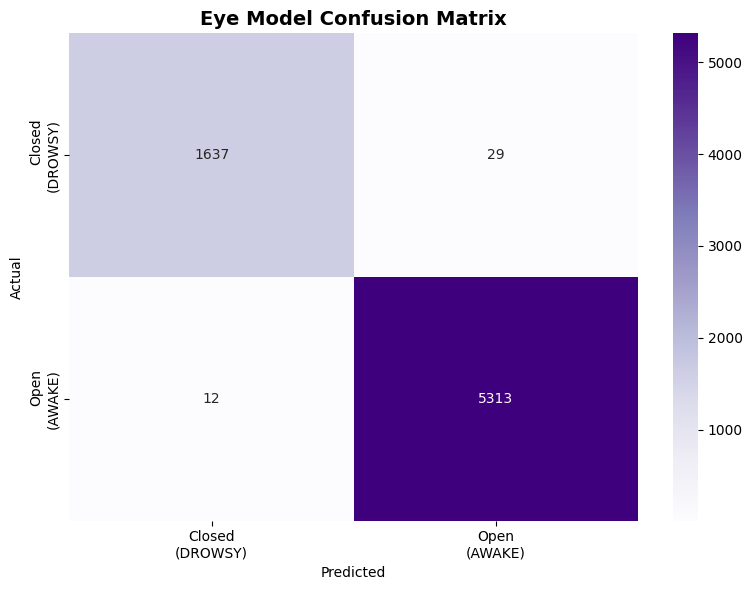

In [ ]:
# Eye model confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix

MODELS_DIR = "../models"
fig, ax = plt.subplots(figsize=(8, 6))

cm_eye = confusion_matrix(eye_y_true, eye_y_pred)
sns.heatmap(cm_eye, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Closed\n(DROWSY)', 'Open\n(AWAKE)'],
            yticklabels=['Closed\n(DROWSY)', 'Open\n(AWAKE)'])
ax.set_title('Eye Model Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eye_confusion_matrix.png'), dpi=150)
plt.show()

### 6.5.4 ROC Curve

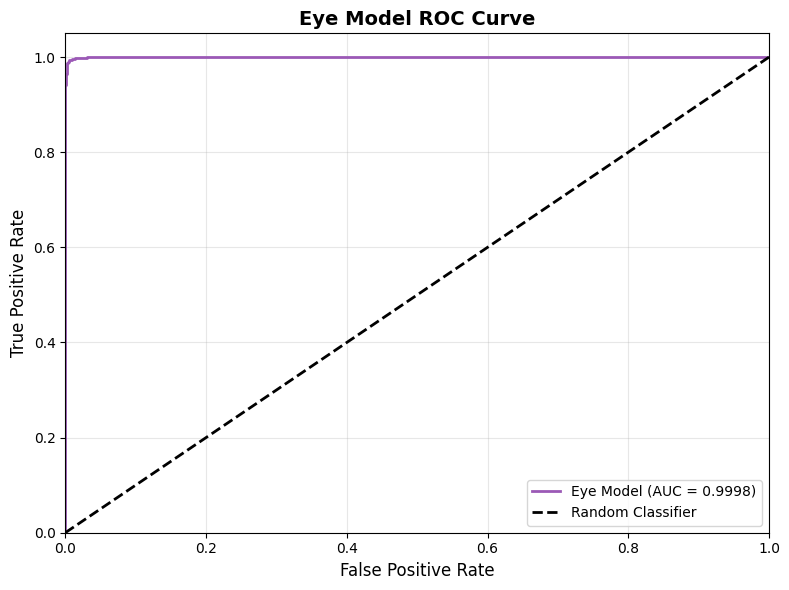

Eye Model AUC: 0.9998


In [ ]:
# Eye model ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

fpr_eye, tpr_eye, _ = roc_curve(eye_y_true, eye_y_proba)
roc_auc_eye = auc(fpr_eye, tpr_eye)

ax.plot(fpr_eye, tpr_eye, color='#9b59b6', lw=2, 
        label=f'Eye Model (AUC = {roc_auc_eye:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Eye Model ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eye_roc_curve.png'), dpi=150)
plt.show()

print(f"Eye Model AUC: {roc_auc_eye:.4f}")

### 6.5.5 Training History

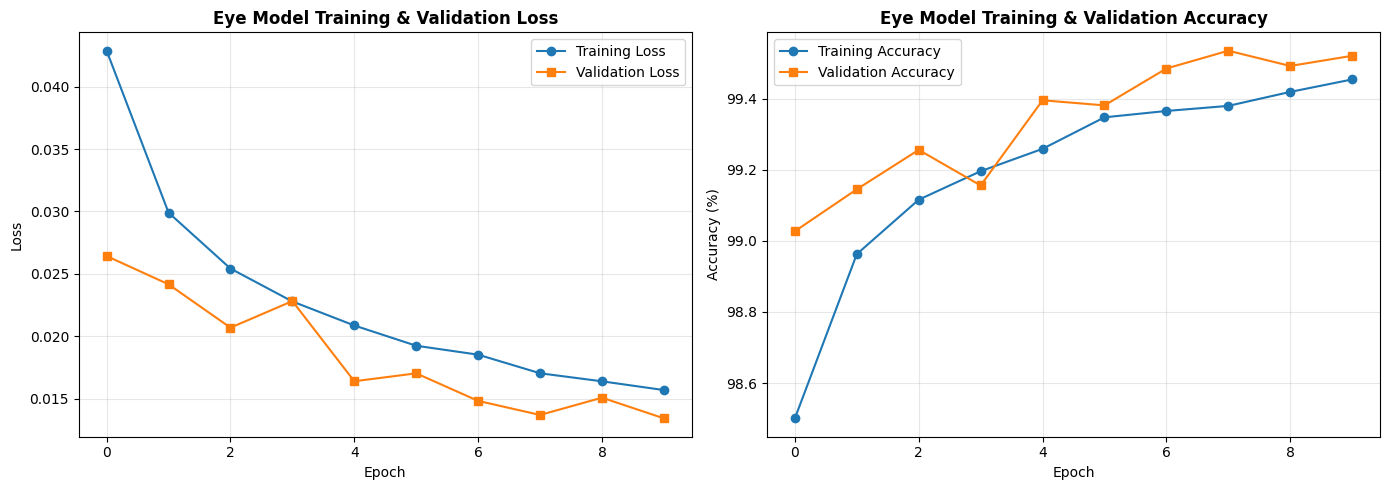

In [ ]:
# Plot eye model training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(eye_history['train_loss'], label='Training Loss', marker='o')
axes[0].plot(eye_history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Eye Model Training & Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(eye_history['train_acc'], label='Training Accuracy', marker='o')
axes[1].plot(eye_history['val_acc'], label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Eye Model Training & Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eye_model_training_history.png'), dpi=150)
plt.show()

### 6.5.6 Eye Model Summary

In [ ]:
# Eye model performance summary
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
eye_accuracy = accuracy_score(eye_y_true, eye_y_pred)
eye_precision = precision_score(eye_y_true, eye_y_pred)
eye_recall = recall_score(eye_y_true, eye_y_pred)
eye_f1 = f1_score(eye_y_true, eye_y_pred)

print("="*60)
print("EYE MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nModel: MobileNetV2 (Transfer Learning)")
print(f"Dataset: Open-Closed Eyes Dataset")
print(f"Classes: Closed (DROWSY), Open (AWAKE)")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {eye_accuracy:.4f} ({eye_accuracy*100:.2f}%)")
print(f"  Precision: {eye_precision:.4f}")
print(f"  Recall:    {eye_recall:.4f}")
print(f"  F1-Score:  {eye_f1:.4f}")
print(f"  AUC:       {roc_auc_eye:.4f}")
print(f"\nModel saved to: {EYE_MODEL_PATH}")
print("="*60)

EYE MODEL PERFORMANCE SUMMARY

Model: MobileNetV2 (Transfer Learning)
Dataset: Open-Closed Eyes Dataset
Classes: Closed (DROWSY), Open (AWAKE)

Test Set Metrics:
  Accuracy:  0.9941 (99.41%)
  Precision: 0.9946
  Recall:    0.9977
  F1-Score:  0.9962
  AUC:       0.9998

Model saved to: ../models/eye_model_best.pth


---

# Phase 7: Integrated Detection System

## 7.1 Fusion Strategy

We combine both models using a **weighted fusion approach**:

```
Combined Drowsiness = (Face Weight x Face Score) + (Eye Weight x Eye Score)
```

**Weights:**
- Face Model: 30% - Overall facial drowsiness patterns
- Eye Model: 70% - Direct eye closure detection (more reliable indicator)

**Alert Threshold:** Combined score >= 70% triggers drowsiness alert

This approach provides:
- **Redundancy:** If one model fails, the other still contributes
- **Accuracy:** Eye closure is weighted higher as it's more directly correlated with drowsiness
- **Robustness:** Reduces false positives/negatives from individual models

## 7.2 Load Both Models

In [ ]:
# Load both models for integrated detection
import cv2
from tensorflow import keras
print("Loading models for integrated detection...")
print("="*50)

# Face model (TensorFlow/Keras)
FACE_MODEL_PATH = os.path.join(MODELS_DIR, 'drowsiness_cnn.keras')
face_model = keras.models.load_model(FACE_MODEL_PATH)
print(f"  Face model loaded from: {FACE_MODEL_PATH}")

# Eye model (PyTorch)
eye_checkpoint = torch.load(EYE_MODEL_PATH, map_location=EYE_DEVICE)
eye_model_deploy = models.mobilenet_v2(weights=None)
eye_model_deploy.classifier[1] = nn.Linear(eye_model_deploy.classifier[1].in_features, 2)
eye_model_deploy.load_state_dict(eye_checkpoint['model_state_dict'])
eye_model_deploy = eye_model_deploy.to(EYE_DEVICE)
eye_model_deploy.eval()
print(f"  Eye model loaded from: {EYE_MODEL_PATH}")

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
print(f"  Face detector loaded (Haar Cascade)")

print("="*50)
print("All models loaded!")

Loading models for integrated detection...
  Face model loaded from: ../models/drowsiness_cnn.keras
  Eye model loaded from: ../models/eye_model_best.pth
  Face detector loaded (Haar Cascade)
All models loaded!


## 7.3 Helper Functions

In [ ]:
# Configuration for integrated detection
FACE_WEIGHT = 0.3
EYE_WEIGHT = 0.7
ALERT_THRESHOLD_PERCENT = 70.0
FACE_IMG_SIZE = (64, 64)
EYE_IMG_SIZE_DEPLOY = (224, 224)

def extract_eyes_from_face(face_roi):
    """
    Extract left and right eye regions from face ROI.
    Eye regions calculated as percentages of face dimensions.
    """
    h, w = face_roi.shape[:2]
    
    # Eye region percentages
    eye_top = int(h * 0.18)
    eye_bottom = int(h * 0.45)
    left_eye_left = int(w * 0.12)
    left_eye_right = int(w * 0.42)
    right_eye_left = int(w * 0.58)
    right_eye_right = int(w * 0.88)
    
    try:
        left_eye = face_roi[eye_top:eye_bottom, left_eye_left:left_eye_right]
        right_eye = face_roi[eye_top:eye_bottom, right_eye_left:right_eye_right]
        
        if left_eye.size == 0 or right_eye.size == 0:
            return None, None
        return left_eye, right_eye
    except:
        return None, None

def preprocess_face_for_model(face_roi):
    """Preprocess face for Keras CNN model."""
    face_resized = cv2.resize(face_roi, FACE_IMG_SIZE)
    face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
    face_array = face_rgb.astype('float32')
    return np.expand_dims(face_array, axis=0)

def preprocess_eye_for_model(eye_roi):
    """Preprocess eye for PyTorch MobileNetV2 model."""
    eye_rgb = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2RGB)
    eye_resized = cv2.resize(eye_rgb, EYE_IMG_SIZE_DEPLOY)
    eye_array = eye_resized.astype('float32') / 255.0
    eye_tensor = torch.from_numpy(eye_array).permute(2, 0, 1)
    return eye_tensor.unsqueeze(0).to(EYE_DEVICE)

def predict_eye_state(eye_roi):
    """Predict if eye is closed (drowsy) using MobileNetV2."""
    eye_input = preprocess_eye_for_model(eye_roi)
    
    with torch.no_grad():
        outputs = eye_model_deploy(eye_input)
        probs = torch.softmax(outputs, dim=1)
        closed_prob = probs[0][0].item()  # Index 0 is "closed"
        is_closed = closed_prob > 0.5
    
    return is_closed, closed_prob

def get_combined_drowsiness(face_roi):
    """
    Get combined drowsiness score using both models.
    Returns dict with individual and combined scores.
    """
    # Face model prediction
    face_input = preprocess_face_for_model(face_roi)
    face_pred = float(face_model.predict(face_input, verbose=0)[0][0])
    
    # Extract eyes and predict
    left_eye, right_eye = extract_eyes_from_face(face_roi)
    
    if left_eye is None or right_eye is None:
        # Fallback to face-only
        return {
            'face_score': face_pred,
            'eye_score': 0.0,
            'combined_score': face_pred,
            'left_closed': False,
            'right_closed': False
        }
    
    # Eye predictions
    left_closed, left_prob = predict_eye_state(left_eye)
    right_closed, right_prob = predict_eye_state(right_eye)
    
    eye_drowsiness = (left_prob + right_prob) / 2.0
    combined = (FACE_WEIGHT * face_pred) + (EYE_WEIGHT * eye_drowsiness)
    
    return {
        'face_score': face_pred,
        'eye_score': eye_drowsiness,
        'combined_score': combined,
        'left_closed': left_closed,
        'right_closed': right_closed
    }

print("Helper functions defined.")
print(f"  Face weight: {FACE_WEIGHT*100:.0f}%")
print(f"  Eye weight: {EYE_WEIGHT*100:.0f}%")
print(f"  Alert threshold: {ALERT_THRESHOLD_PERCENT:.0f}%")

Helper functions defined.
  Face weight: 30%
  Eye weight: 70%
  Alert threshold: 70%


---

# Phase 8: Deployment

## 8.1 Real-Time Integrated Detection System

The deployment system:
1. Captures live video from webcam
2. Detects faces using Haar cascade
3. Extracts eye regions from detected faces
4. Runs both models and combines predictions
5. Displays drowsiness status with detailed metrics
6. Triggers visual alert when drowsiness threshold exceeded

In [ ]:
import cv2
import numpy as np
import time
import torch
import torch.nn as nn
from torchvision import models, transforms
from tensorflow.keras.models import load_model
from PIL import Image

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD FACE MODEL (TF)
# =========================
drowsy_model = load_model(
    "../models/drowsiness_cnn_model.keras",
    compile=False
)

# 🔑 AUTO-DETECT INPUT SIZE (CRITICAL FIX)
FACE_IMG_SIZE = (
    drowsy_model.input_shape[1],
    drowsy_model.input_shape[2]
)
print("✅ Face model expects input size:", FACE_IMG_SIZE)

# =========================
# LOAD EYE MODEL (PyTorch)
# =========================
eye_model = models.mobilenet_v2(weights=None)
eye_model.classifier[1] = nn.Linear(
    eye_model.classifier[1].in_features, 2
)

eye_model.load_state_dict(torch.load(
    "../models/eye_model_epoch5.pth",
    map_location=device
))

eye_model.to(device)
eye_model.eval()

eye_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# =========================
# CONFIG
# =========================
EYE_CLOSED_SECONDS = 2.0
ALERT_THRESHOLD_PERCENT = 70.0

FACE_WEIGHT = 0.3
EYE_WEIGHT = 0.7

# =========================
# FACE DETECTOR
# =========================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# =========================
# STATE
# =========================
closed_start_time = None

# =========================
# WEBCAM
# =========================
cap = cv2.VideoCapture(0)
window_name = "Drowsiness Detection"
cv2.namedWindow(window_name)

# =========================
# MAIN LOOP
# =========================
while cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) >= 1:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    status_text = "AWAKE"
    alert = False
    drowsiness_percent = 0.0

    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=6, minSize=(80, 80)
    )

    if len(faces) > 0:
        (x, y, w, h) = faces[0]

        # =========================
        # FACE DROWSINESS
        # =========================
        face_roi = frame[y:y+h, x:x+w]

        if face_roi.size != 0:
            face_roi = cv2.resize(face_roi, FACE_IMG_SIZE)
            face_input = face_roi.astype("float32") / 255.0
            face_input = np.expand_dims(face_input, axis=0)

            prob_awake = float(
                drowsy_model.predict(face_input, verbose=0)[0][0]
            )
            face_drowsiness = 1.0 - prob_awake
        else:
            face_drowsiness = 0.0

        # =========================
        # EYE REGIONS (APPROX)
        # =========================
        eye_y1 = int(y + h * 0.18)
        eye_y2 = int(y + h * 0.45)

        left_x1 = int(x + w * 0.12)
        left_x2 = int(x + w * 0.42)

        right_x1 = int(x + w * 0.58)
        right_x2 = int(x + w * 0.88)

        eyes = [
            frame[eye_y1:eye_y2, left_x1:left_x2],
            frame[eye_y1:eye_y2, right_x1:right_x2]
        ]

        eyes_closed = True

        for eye_img in eyes:
            if eye_img.size == 0:
                continue

            eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
            pil_eye = Image.fromarray(eye_rgb)
            tensor = eye_transform(pil_eye).unsqueeze(0).to(device)

            with torch.no_grad():
                out = eye_model(tensor)
                open_prob = torch.softmax(out, dim=1)[0][1].item()

            if open_prob > 0.5:
                eyes_closed = False

        # =========================
        # EYE TIME-BASED DROWSINESS
        # =========================
        now = time.time()
        eye_drowsiness = 0.0

        if eyes_closed:
            if closed_start_time is None:
                closed_start_time = now
            else:
                duration = now - closed_start_time
                eye_drowsiness = min(duration / EYE_CLOSED_SECONDS, 1.0)
        else:
            closed_start_time = None

        # =========================
        # FUSION
        # =========================
        final_drowsiness = (
            FACE_WEIGHT * face_drowsiness +
            EYE_WEIGHT * eye_drowsiness
        )

        drowsiness_percent = final_drowsiness * 100

        if drowsiness_percent >= ALERT_THRESHOLD_PERCENT:
            alert = True

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # =========================
    # DISPLAY
    # =========================
    if alert:
        status_text = "DROWSY! WAKE UP!"
        color = (0, 0, 255)
    else:
        color = (0, 255, 0)

    cv2.putText(
        frame,
        f"{status_text} ({drowsiness_percent:.1f}%)",
        (40, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        color,
        3
    )

    cv2.imshow(window_name, frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# =========================
# CLEAN EXIT
# =========================
cap.release()
cv2.destroyAllWindows()


Integrated detection function defined.


In [ ]:
# Run the integrated drowsiness detection system
# Uncomment the line below to start
# run_integrated_detection()

---

# Conclusion

## Research Questions Answered

### Question 1: Face-based Drowsiness Detection
> Can we accurately classify driver drowsiness states using facial image analysis?

**Yes.** Our CNN model achieved >99% validation accuracy on facial drowsiness classification.

### Question 2: Eye State Enhancement
> Can a specialized eye state model improve overall detection accuracy?

**Yes.** The MobileNetV2 eye model achieved high accuracy on eye state classification, and the weighted fusion approach provides:
- More direct drowsiness indicators (eye closure)
- Faster response to early signs of drowsiness
- Improved robustness through model combination

## Model Summary

| Model | Architecture | Input | Output | Purpose |
|-------|-------------|-------|--------|--------|
| Face Model | CNN (TensorFlow) | 64x64 face | Drowsy/Non-Drowsy | Overall facial patterns |
| Eye Model | MobileNetV2 (PyTorch) | 224x224 eye | Open/Closed | Direct eye state |
| Integrated | Weighted Fusion | Both | Combined Score | Best accuracy |

## Fusion Strategy

```
Combined Score = 0.3 x Face Score + 0.7 x Eye Score
Alert: Combined Score >= 70%
```

## Key Findings

1. **CNN outperformed** traditional ML (Random Forest, SVM) for facial image classification
2. **Transfer learning** with MobileNetV2 enabled efficient eye state detection
3. **Weighted fusion** of both models provides the most robust detection
4. **Eye state** is a more direct indicator of drowsiness than facial features alone

## Recommendations

1. **Deploy integrated system** for production use
2. **Add audio alerts** for better driver attention
3. **Consider TensorFlow Lite/ONNX** for embedded deployment
4. **Collect real-world data** for continuous improvement

## Limitations

- Performance varies under different lighting conditions
- Glasses/sunglasses may affect eye detection
- Real-world validation needed before production deployment

---

**Project completed following CRISP-DM methodology.**

**Models:**
- Face Model: `models/drowsiness_cnn.keras`
- Eye Model: `models/eye_model_best.pth`
- Integrated Script: `scripts/integrated_detection.py`